In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt


ss = hf.settings_dict()
import helpers.sig_stc as sig_stc

loading dataset for subject:  0005_3SJ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.291 s, (-6.4, -79.1, -6.9) mm, [7, 3, 7] vox, 2152 vertex
Using control points [1.91769079 2.13837696 4.1146029 ]


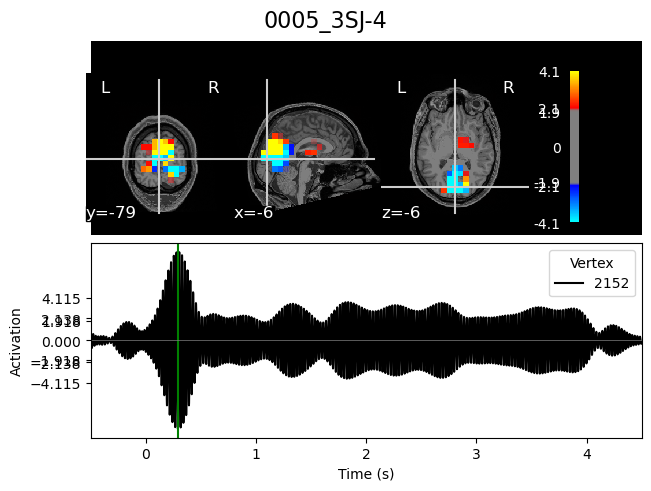

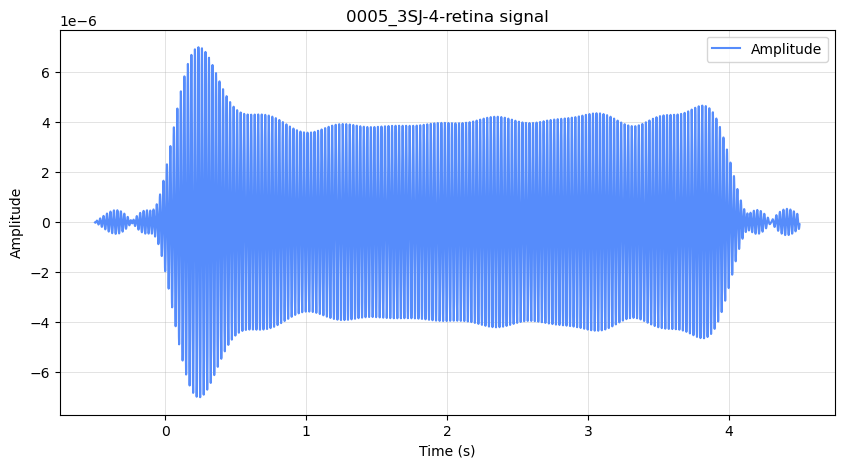

loading dataset for subject:  0002_TCZ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.193 s, (19.1, -70.0, 39.6) mm, [10, 3, 10] vox, 3844 vertex
Using control points [1.47851356 1.66168626 3.0194651 ]


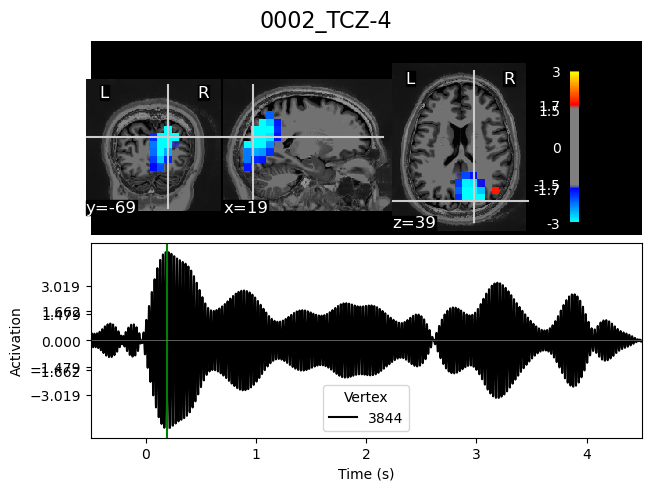

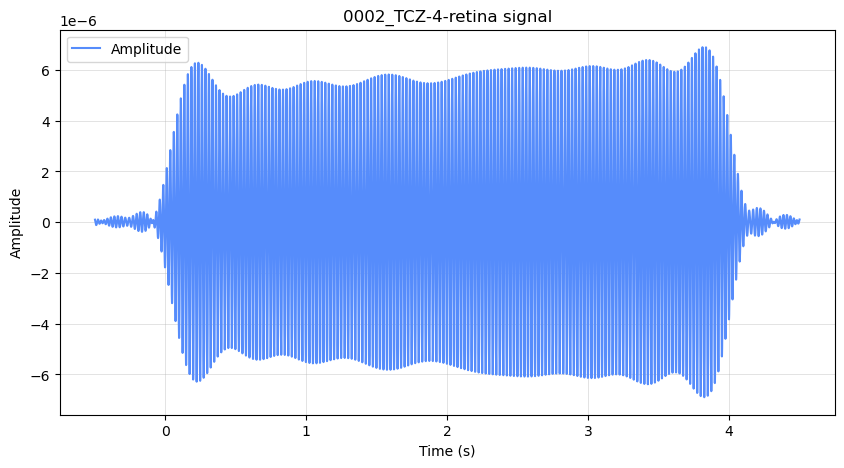

loading dataset for subject:  0009_YGZ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1225 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.476 s, (7.1, -75.3, 44.5) mm, [8, 2, 9] vox, 2603 vertex
Using control points [1.77269914 1.97179894 3.84550255]


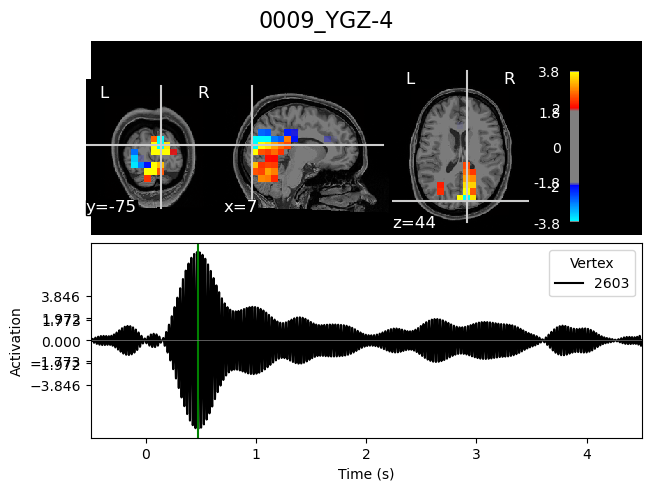

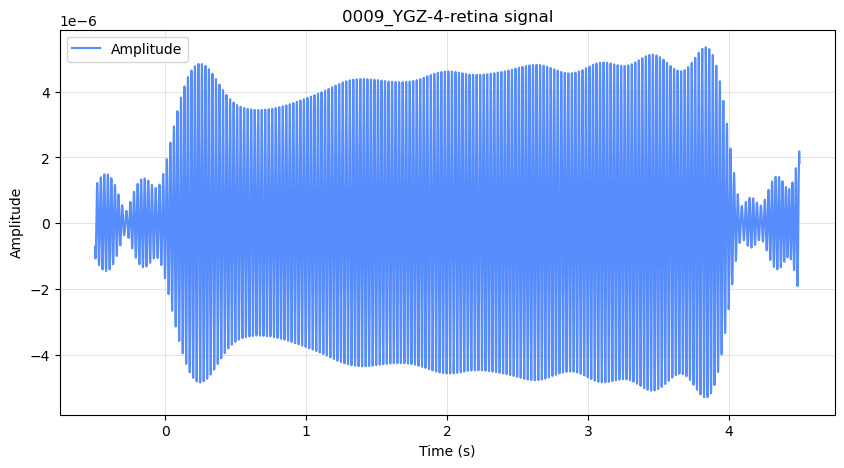

loading dataset for subject:  0010_ZMG
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0010_ZMG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.323 s, (-14.4, -71.3, -5.6) mm, [6, 3, 7] vox, 2151 vertex
Using control points [1.57448872 1.74899611 3.16412904]


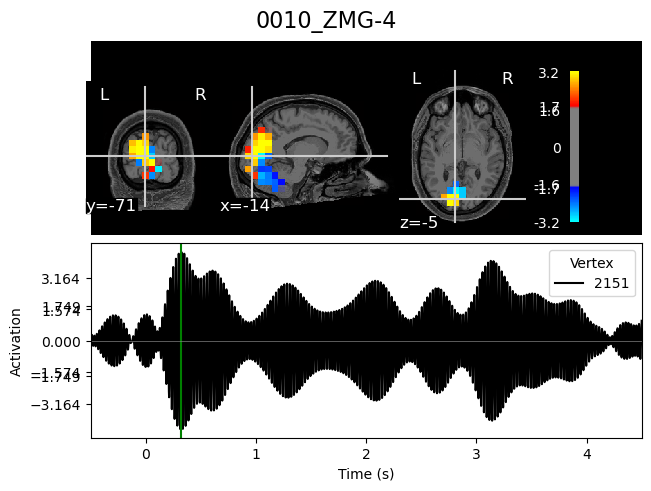

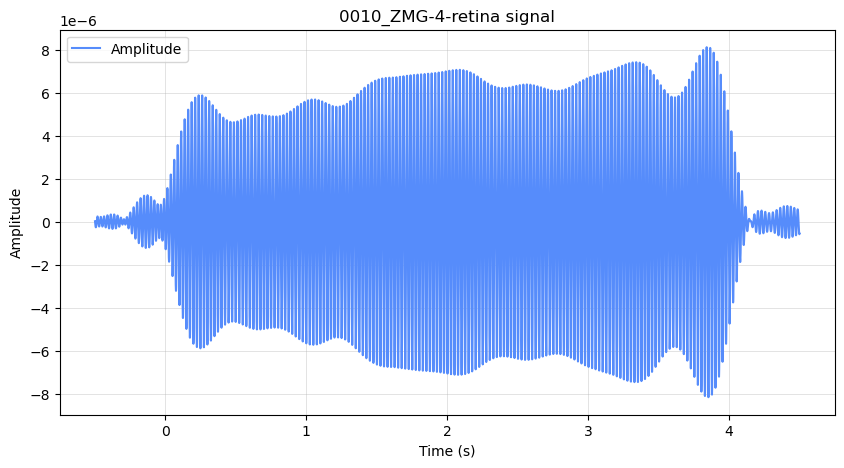

In [2]:
event_name = "4"

for subject_index in ss['subject_idx_list']:
    subjects_dir = ss['fs_subjects_dir']
    subject = ss['subject_id_list'][subject_index]
    print("loading dataset for subject: ", subject)

    stc_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-vol.stc"

    stc = mne.read_source_estimate(stc_file)

    fwd_fname = op.join(ss['fwd_dir'], subject + '-fwd.fif')
    fwd = mne.read_forward_solution(fwd_fname)
    src = fwd['src']

    if src[0]['subject_his_id'].startswith("fs"):
        src[0]['subject_his_id'] = subject

    brain = mne.viz.plot_volume_source_estimates(
        stc,
        subject=subject,
        subjects_dir=subjects_dir,
        src=src,
        show=False,)
    # Add a title to the figure
    brain.suptitle(f"{subject}-{event_name}", fontsize=16)

    # Display the plot
    plt.show()

    # Plot the retina signal over time

    retina_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-retina.csv"

    # Read the CSV file
    df = pd.read_csv(retina_file)

    # Plot amplitude over time
    plt.figure(figsize=(10, 5))
    plt.plot(df["time_s"], df["amplitude"], label="Amplitude")

    # Labels and title
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{subject}-{event_name}-retina signal")
    plt.grid(True)
    plt.legend()

    # Show the plot
    plt.show()

    del stc




Subject: s1/0005_3SJ is selected
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/raw/0005/20180514_000000/MEG/001.flicker/files/flicker.fif...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:41: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/raw/0005/20180514_000000/MEG/001.flicker/files/flicker.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_fname1, preload=preload)  # raw meg data


    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 73000 ... 1218999 =     36.500 ...   609.500 secs
Ready.
Reading 0 ... 1145999  =      0.000 ...   573.000 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:49: RuntimeWarning: The unit for channel(s) MISC001 has changed from V to NA.
  raw.set_channel_types(mapping={'MISC001': 'misc'})


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 38 - 42 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 38.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 37.50 Hz)
- Upper passband edge: 42.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 42.50 Hz)
- Filter length: 6601 samples (3.300 s)

Not setting metadata
70 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 70 events and 8600 original time points ...


...

Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 1440 sources


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:91: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filters = make_lcmv(epochs_all.info,


Filter computation complete
Not setting metadata
10 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 10 events and 8600 original time points ...
0 bad epochs dropped


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:99: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  epochs = mne.Epochs(raw,
/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:111: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad 

Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.292 s, (3.6, -69.1, -6.9) mm, [8, 4, 7] vox, 2168 vertex
Using control points [2.04738968 2.2857606  4.88377906]


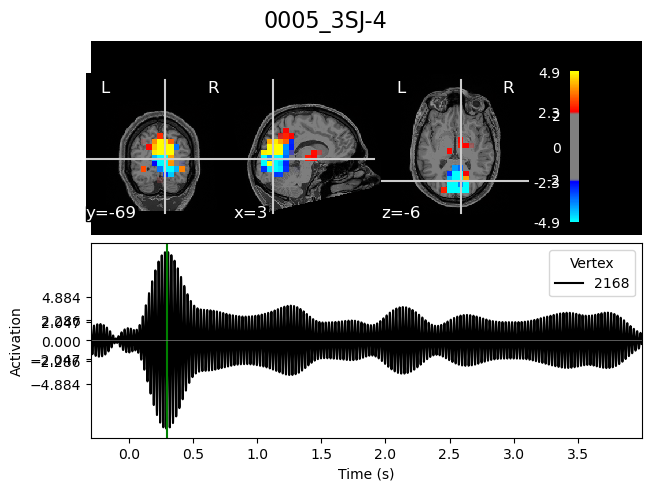

Subject: s2/0002_TCZ is selected
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/raw/0002/20180522_000000/MEG/001.s2/files/s2.fif...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:41: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/raw/0002/20180522_000000/MEG/001.s2/files/s2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_fname1, preload=preload)  # raw meg data


    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 93000 ... 1274999 =     46.500 ...   637.500 secs
Ready.
Reading 0 ... 1181999  =      0.000 ...   591.000 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:49: RuntimeWarning: The unit for channel(s) MISC001 has changed from V to NA.
  raw.set_channel_types(mapping={'MISC001': 'misc'})


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 38 - 42 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 38.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 37.50 Hz)
- Upper passband edge: 42.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 42.50 Hz)
- Filter length: 6601 samples (3.300 s)

Not setting metadata
70 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 70 events and 8600 original time points ...


...

Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 1868 sources
Filter computation complete
Not setting metadata
10 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 10 events and 8600 original time points ...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:91: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filters = make_lcmv(epochs_all.info,
/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:99: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channel

0 bad epochs dropped
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:111: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  stc = mne.beamformer.apply_lcmv(evoked,filters)


    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.335 s, (19.1, -70.0, 39.6) mm, [10, 3, 10] vox, 3844 vertex
Using control points [1.54369379 1.73509543 3.45254325]


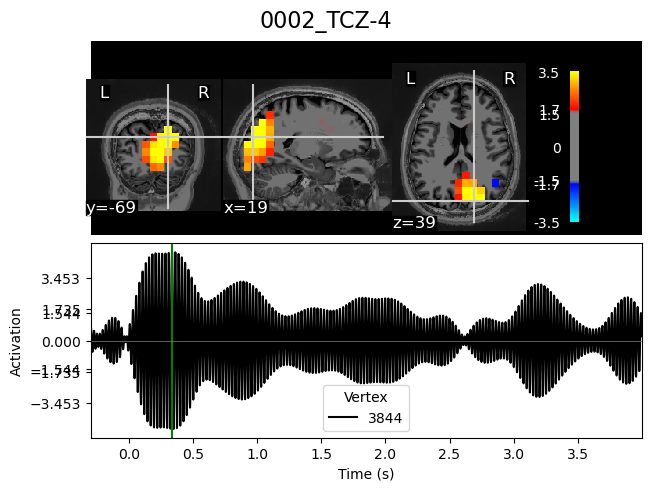

Subject: s3/0009_YGZ is selected
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1225 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/raw/0009/20180522_000000/MEG/001.s3p1/files/s3p1.fif...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:37: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/raw/0009/20180522_000000/MEG/001.s3p1/files/s3p1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw1 = mne.io.read_raw_fif(raw_fname1, preload=preload)


    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 53000 ... 711999 =     26.500 ...   356.000 secs
Ready.
Reading 0 ... 658999  =      0.000 ...   329.500 secs...
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/raw/0009/20180522_000000/MEG/002.s3p2/files/s3p2.fif...
    Read a

/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:38: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/raw/0009/20180522_000000/MEG/002.s3p2/files/s3p2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw2 = mne.io.read_raw_fif(raw_fname2, preload=preload)


    Range : 38000 ... 540999 =     19.000 ...   270.500 secs
Ready.
Reading 0 ... 502999  =      0.000 ...   251.500 secs...


...

Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 1225 sources
Filter computation complete
Not setting metadata
10 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 10 events and 8600 original time points ...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:91: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filters = make_lcmv(epochs_all.info,
/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:99: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channel

0 bad epochs dropped
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:111: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  stc = mne.beamformer.apply_lcmv(evoked,filters)


    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1225 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.451 s, (7.1, -75.3, 34.5) mm, [8, 2, 8] vox, 2318 vertex
Using control points [1.84885143 2.06973289 4.58258828]


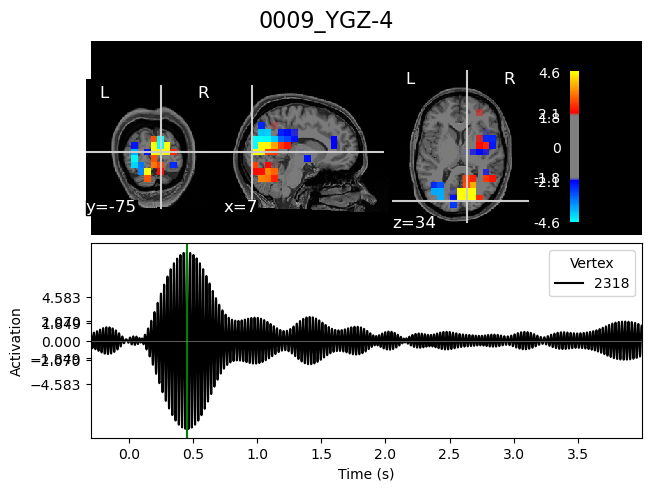

Subject: s4/0010_ZMG is selected
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0010_ZMG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/raw/0010/20180523_000000/MEG/001.s4/files/s4.fif...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:41: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/raw/0010/20180523_000000/MEG/001.s4/files/s4.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_fname1, preload=preload)  # raw meg data


    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 87000 ... 1286999 =     43.500 ...   643.500 secs
Ready.
Reading 0 ... 1199999  =      0.000 ...   600.000 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:49: RuntimeWarning: The unit for channel(s) MISC001 has changed from V to NA.
  raw.set_channel_types(mapping={'MISC001': 'misc'})


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 38 - 42 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 38.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 37.50 Hz)
- Upper passband edge: 42.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 42.50 Hz)
- Filter length: 6601 samples (3.300 s)

Not setting metadata
70 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 70 events and 8600 original time points ...


...

Creating the source covariance matrix
Adjusting source covariance matrix.
Computing beamformer filters for 1212 sources
Filter computation complete
Not setting metadata
10 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 10 events and 8600 original time points ...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:91: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filters = make_lcmv(epochs_all.info,
/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:99: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channel

0 bad epochs dropped
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0010_ZMG-fwd.fif...
    Reading a source space...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/sig_stc.py:111: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  stc = mne.beamformer.apply_lcmv(evoked,filters)


    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.323 s, (-14.4, -71.3, -5.6) mm, [6, 3, 7] vox, 2151 vertex
Using control points [1.6385007  1.82704883 3.46427404]


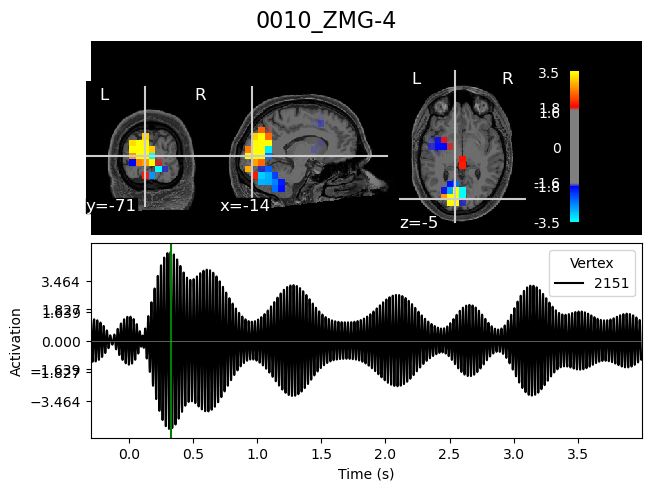

In [3]:
# use sigbjornmne's code as a reference
event_id = 4

for subject_index in ss['subject_idx_list']:

    stc = sig_stc.make_sig_stc(subject_index, event_id)

    subjects_dir = ss['fs_subjects_dir']
    subject = ss['subject_id_list'][subject_index]

    fwd_fname = op.join(ss['fwd_dir'], subject + '-fwd.fif')
    fwd = mne.read_forward_solution(fwd_fname)
    src = fwd['src']

    if src[0]['subject_his_id'].startswith("fs"):
        src[0]['subject_his_id'] = subject

    brain = mne.viz.plot_volume_source_estimates(
        stc,
        subject=subject,
        subjects_dir=subjects_dir,
        src=src,
        show=False,)
    # Add a title to the figure
    brain.suptitle(f"{subject}-{event_name}", fontsize=16)

    # Display the plot
    plt.show()

    del stc

In [4]:
# variables
voxel = 477
event_name = "4"
subject_index = 0

loading dataset for subject:  0005_3SJ
Reading forward solution from /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Showing: t = 0.278 s, (-6.4, -69.1, -6.9) mm, [7, 4, 7] vox, 2167 vertex
Using control points [0.        0.        0.7991976]


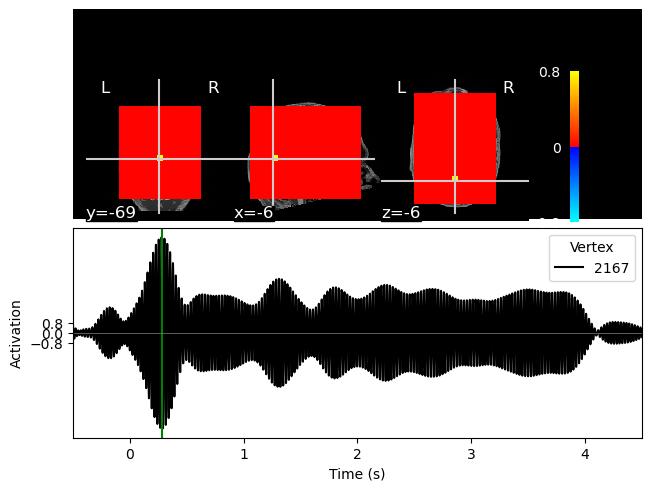

['_PROPERTIES_EXCLUDED_FROM_SET',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_axes_internal',
 '_agg_filter',
 '_align_label_groups',
 '_alpha',
 '_animated',
 '_axobservers',
 '_axstack',
 '_button_pick_id',
 '_callbacks',
 '_canvas_callbacks',
 '_check_layout_engines_compat',
 '_clipon',
 '_clippath',
 '_cm_set',
 '_different_canvas',
 '_dpi',
 '_fully_clipped_to_axes',
 '_gci',
 '_get_dpi',
 '_get_draw_artists',
 '_get_renderer',
 '_gid',
 '_in_layout',
 '_internal_update',
 '_label',
 '_layout_engine',
 '_localaxes',
 '_mouse_key_ids',
 '_mouseover',
 '_norm_per_subplot_kw',
 

In [5]:


import numpy as np

subjects_dir = ss['fs_subjects_dir']
subject = ss['subject_id_list'][subject_index]
print("loading dataset for subject: ", subject)

stc_file = Path(ss['stc_dir']) / subject / event_name / f"{subject}-event-{event_name}-vol.stc"

stc = mne.read_source_estimate(stc_file)

fwd_fname = op.join(ss['fwd_dir'], subject + '-fwd.fif')
fwd = mne.read_forward_solution(fwd_fname)
src = fwd['src']

if src[0]['subject_his_id'].startswith("fs"):
    src[0]['subject_his_id'] = subject

voxel = 477

data = np.zeros_like(stc.data)
data[voxel, :] = stc.data[voxel, :]

stc_single = mne.VolSourceEstimate(
    data,
    vertices=stc.vertices,
    tmin=stc.tmin,
    tstep=stc.tstep,
    subject=stc.subject,
)

brain = stc_single.plot(
    src=src,
    subject=subject,
    subjects_dir=subjects_dir,
)

dir(brain)